In [1]:
import pandas as pd
import numpy as np
import polars as pl
import plotly.graph_objects as go

from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# data loading
import sys
sys.path.insert(0, '/Users/zzhu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

# plot
import plotly.express as px

# exchange data info
# https://api.tardis.dev/v1/exchanges/binance

# For generate_combination function
import json
from itertools import product
from typing import List, Dict, Tuple

# For Tardis download error
from urllib.error import HTTPError

# For pandas print setting
pd.set_option('display.width', None)  # Automatically adjust the width of the display
pd.set_option('display.max_colwidth', None)

In [2]:
# Load the format config
with open("./config/format_cfg.json", "r") as f:
    format_cfg = json.load(f)

# Load Tardis credential
root_dir = './Data'
api_key = 'TD.sSGNjEpohBl9i0FV.zz0-s-b6DZ9c2lt.uoNpgBPGaTITrA9.YlW26JKS0PSfoOG.2pEnnkHAnTpOloD.3wMo'

Tardis_data = TardisLoader(root_dir, api_key)

In [43]:
# start_time = datetime.strptime("2024-12-05", "%Y-%m-%d")
# end_time = datetime.strptime("2024-12-05", "%Y-%m-%d")

# test = Tardis_data.read(start_time, end_time, data_type='trades', exchange='bybit-spot', symbol='BTCUSDT')

In [5]:
def generate_combinations(
    data_type: List[str],
    exchange: List[str],
    symbol: List[str],
    format_config: Dict
) -> List[Tuple[str, str, str]]:
    """
    Generate all possible combinations of data_type, exchange, and symbol,
    while formatting exchange and symbol based on the provided format_config.
    """
    combinations = []

    for dt, ex, sym in product(data_type, exchange, symbol):
        # Extract the base exchange name (e.g., 'bybit' from 'bybit-spot')
        base_exchange, market_type = ex.split('-')
        
        # Ensure the base exchange and market type exist in the config
        if base_exchange in format_config and market_type in format_config[base_exchange]:
            # Format the exchange
            formatted_exchange = format_config[base_exchange][market_type]["exchange"]
            
            # Format the symbol
            symbol_format = format_config[base_exchange][market_type]["symbol"]
            formatted_symbol = sym.lower() + symbol_format
            
            # Append the tuple
            combinations.append((dt, formatted_exchange, formatted_symbol))

    return combinations

In [7]:
# Create a 10ms interval time range to align different dfs
def create_microsecond_range(start_date: str, end_date: str, interval: str) -> pl.Series:
    """
    Create a Polars Series with a range of timestamps in microseconds.

    Args:
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        interval (str): Interval duration in Polars-compatible format (e.g., '10ms').

    Returns:
        pl.Series: A Polars Series with timestamps in microseconds.
    """
    # Define start and end times
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d") + timedelta(days=1) - timedelta(microseconds=1)

    # Use polars.date_range to generate the series
    date_series = pl.datetime_ranges(
        start=start,
        end=end,
        interval=interval,
        time_unit='us',
        closed="both",
        eager=True  # Generate the range immediately
    )
    
    df = pl.DataFrame(
        date_series[0].dt.timestamp("us").cast(pl.Int64).alias('timestamp')
    )

    return df

In [9]:
def cross_arb_test(start_time_str: str, end_time_str: str, exchanges: list[str], symbols: list[str], data_types: list[str], fees: dict) -> pl.DataFrame:
    '''
    granularity='50ms'
    '''
    # Download the dataset - Nov 7 vs Today
    start_time = datetime.strptime(start_time_str, "%Y-%m-%d")
    end_time = datetime.strptime(end_time_str, "%Y-%m-%d")

    # Convert the exchanges' and symbols' format according to format_cfg
    combinations = generate_combinations(data_types, exchanges, symbols, format_cfg)

    venues = []
    
    for comb in combinations:
        try:
            # Tardis_data.download(start_time, end_time, data_type=comb[0], exchange=comb[1], symbol=comb[2])
            data = Tardis_data.read(start_time, end_time, data_type=comb[0], exchange=comb[1], symbol=comb[2])
            venues.append(data)
        except HTTPError:
            print(f'{comb[2]} {comb[0]} not avaliable on {comb[1]}.')
        except Exception as e:
            print(e)
    
    if len(venues) <= 1:
        print(f'{symbols[0]} exists on less than two exchanges, thus unable to arb, skip')
        return pl.DataFrame(), None
            
    # Initiaze timestamps
    df = create_microsecond_range(start_time_str, end_time_str, '10ms')

    # Join the bbo data from 3 exchanges to initial timestamp
    venue_names = []
    for venue in venues:
        venue_name = venue[0]['exchange'][0]
        venue_fee = fees[venue_name]
        venue_names.append(venue_name)
        if venue_name == 'kucoin':
            tmp_df = venue.sort(by='local_timestamp')
            
            tmp_df = tmp_df.group_by_dynamic("local_timestamp", every='10000i', closed="right", label='right').agg([
                (pl.col("ask_price").last() * (1 + venue_fee)).alias(f'ask_price_{venue_name}'),
                (pl.col("bid_price").last() * (1 - venue_fee)).alias(f'bid_price_{venue_name}')
            ])
            df = df.join(tmp_df, left_on="timestamp", right_on="local_timestamp", how='left')
        else:
            tmp_df = venue.group_by_dynamic("timestamp", every='10000i', closed="right", label='right').agg([
                (pl.col("ask_price").last() * (1 + venue_fee)).alias(f'ask_price_{venue_name}'),
                (pl.col("bid_price").last() * (1 - venue_fee)).alias(f'bid_price_{venue_name}')
            ])
            df = df.join(tmp_df, left_on="timestamp", right_on="timestamp", how='left')

    # Fill empty price use latest price we saw, and drop those still nulls after forward fill.
    df = df.fill_null(strategy="forward").drop_nulls()
    
    # Calculate the cross venue bbo diveregence using the bbo data from 3 exchanges
    df = df.lazy().with_columns([
        pl.min_horizontal([col for col in df.columns if 'ask_price' in col]).alias('best_ask'),
        pl.max_horizontal([col for col in df.columns if 'bid_price' in col]).alias('best_bid'),
    ]).with_columns([
        ((pl.col('best_bid') - pl.col('best_ask')) / pl.col('best_ask') * 10000).round(1).alias('bbo_divergence_bps')
    ]).collect()
    
    return df, venue_names

In [603]:
def divergence_plot(df: pl.DataFrame) -> None:
    df = df.to_pandas()

    # Convert timestamp to human-readable datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='us')
    df = df.resample('10s', on='timestamp').first().reset_index()
    
    price_name = df.columns[1]

    # Create figure
    fig = go.Figure()

    # Price line
    fig.add_trace(go.Scatter(
        x=df['timestamp'],
        y=df[price_name],
        mode='lines',
        name='Price',
        line=dict(width=2)
    ))

    # Volume bars
    fig.add_trace(go.Bar(
        x=df['timestamp'],
        y=df['bbo_divergence_bps'],
        name='Divergence',
        yaxis='y2',
        opacity=0.6
    ))

    # Update layout to mimic exchange style
    fig.update_layout(
        title='Price & Divergence Chart',
        xaxis=dict(
            rangeslider=dict(visible=False),
            type='date',
        ),
        yaxis=dict(
            title='Price',
            side='right'
        ),
        yaxis2=dict(
            title='Divergence',
            overlaying='y',
            side='left',
            position=0.05,
            anchor='free',
            showgrid=False
        ),
        bargap=0,
        height=600,
        legend=dict(orientation="h"),
    )

    fig.show()

In [930]:
start_time_str = "2025-03-19"
end_time_str = "2025-03-19"
exchanges = ['bybit-perp', 'gate-perp', 'binance-perp'] # 'kraken-spot', 'kucoin',  'okx-spot', 'binance-perp', 'binance-spot'
data_types = ['book_ticker']

fees = {
    'bybit-spot': 0.001, # 0.00015
    'binance': 0.001, # 0.0003
    'okex': 0.001, # 0.0003
    'gate-io': 0.001, # 0.00022
    'kucoin': 0.001, # 0.00035
    'bitget': 0.001,
    'bybit': 0.001,
    'binance-futures': 0.001,
    'gate-io-futures': 0.001,
    'okex-swap': 0.001
}

coin_lists = ['ACT', 'AERO', 'AI16Z', 'ANDY', 'APU', 'BENDOG', 'BABYDOGE', 'BAN', 'BONE', 'BONK', 'BRETT', 'BILLY', 'BONDU'
              'CHEEMS', 'CHILLGUY', 'COQ', 'DEGEN', 'DOG', 'DOGE', 'DOGS', 'ELON', 'FARTCOIN', 'FLOKI', 'FWOG', 
              'GIGA', 'GOAT', 'GRASS', 'GLMR', 'GME', 'HIPPO', 'IP', 'LUCE', 'MEW', 'MOG', 'MOODENG', 
              'NOT','NPC', 'OSAK', 'PEPE', 'PEPECOIN', 'PONKE', 'POPCAT', 'PUFFER', 'PUNT', 'PENGU',
              'SENK','SHIB', 'SLERF', 'SNX', 'SPX', 'SUI', 'SUNDOG', 'SWELL', 'TAO', 'WIF', 'WOJAK', 'WOLF', 'ZEUS']

coin_lists = ['TUT']

# divergence bps threshold
entry_bps_thresh = 60
exit_bps_thres = 0

# arb opportunity lasting time threshold, ms
arb_last_time = 0

# Create a list to save the result
res = []

for coin in coin_lists:
    arb_stats, venue_names = cross_arb_test(start_time_str, end_time_str, exchanges, [coin], data_types, fees)

    if arb_stats.is_empty():
        continue
    else:
        # Total time range
        time_range = arb_stats['timestamp'][-1] - arb_stats['timestamp'][0]
        
        # Process the whole time-align dataframe arb_stats
        stat = arb_stats.with_columns(
            pl.when(pl.col('bbo_divergence_bps') >= entry_bps_thresh).then(pl.lit(1))
            .when(pl.col('bbo_divergence_bps') <= exit_bps_thres).then(pl.lit(-1))
            .otherwise(pl.lit(0))
            .alias('entry_exit')
            ).filter(
                pl.col('entry_exit') != 0
            ).with_columns(
                (pl.col('entry_exit').diff().abs()/2).cum_sum().cast(pl.Int32).alias('bucket_id')
            ).drop_nulls().group_by('bucket_id').agg([
                pl.col('bbo_divergence_bps').max().alias('peak_divergece'),
                pl.col('timestamp').first().alias('arb_start_ts'),
                pl.col('timestamp').last().alias('arb_end_ts'),
                ((pl.col('timestamp').last() - pl.col('timestamp').first())/1000).alias('arb_last_time'),
                pl.col('entry_exit').first().alias('entry_exit')
            ]).sort(by='bucket_id').with_columns(
                (pl.col('arb_start_ts').diff(-1).abs()/1000).alias('entry_exit_last_time')
            ).filter(
                pl.col('entry_exit') == 1
            ).filter(pl.col('arb_last_time') > arb_last_time)
        
        
        # Count the exchanges for each arb, str[10:] is to exclude the first 10 letters, i.e. 'bid/ask_price'
        # Here we use pandas idxmax/min method, since the table is small
        turnover_count = stat.join(arb_stats, left_on='arb_start_ts', right_on = 'timestamp', how='left').to_pandas()
        turnover_count['max_bid_exch'] = turnover_count[[col for col in turnover_count.columns if 'bid_price' in col]].idxmax(axis=1).str[10:]
        turnover_count['min_ask_exch'] = turnover_count[[col for col in turnover_count.columns if 'ask_price' in col]].idxmin(axis=1).str[10:]

        # Select those
        time_ratio = round((stat['arb_last_time'].sum() / time_range), 6)
        stat_des = stat['peak_divergece'].describe()
        arb_counts = stat_des['value'][0]
        if arb_counts > 0:
            single_stat = {'symbol': coin, 'arb_counts': arb_counts,
                           'peak_arb_mean': round(stat_des.filter(pl.col('statistic')=='mean')['value'][0], 2),
                           'peak_arb_median': round(stat_des.filter(pl.col('statistic')=='50%')['value'][0], 2),
                           'peak_arb_max': round(stat_des.filter(pl.col('statistic')=='max')['value'][0], 2),
                           'avaliable_venues': venue_names,
                           'average_arb_time': round(stat['arb_last_time'].mean(), 1),
                           'median_arb_time': stat['arb_last_time'].median(),
                           'longest_arb_time': stat['arb_last_time'].max(),
                           'average_turnover_time': round(stat['entry_exit_last_time'].mean(), 1),
                           'median_turnover_time': stat['entry_exit_last_time'].median(),
                           'longest_turnover_time': stat['entry_exit_last_time'].max(),
                           # 'arb_time_fraction': time_ratio,
                           'max_bid_counts(sell)': turnover_count['max_bid_exch'].value_counts().to_dict(),
                           'min_ask_counts(buy)': turnover_count['min_ask_exch'].value_counts().to_dict()
                          }
        else:
            single_stat = {'symbol': coin, 'arb_counts': 0,
                           'peak_arb_mean': 0,
                           'peak_arb_median': 0,
                           'peak_arb_max': 0,
                           'avaliable_venues': venue_names,
                           'average_arb_time': 0,
                           'median_arb_time': 0,
                           'longest_arb_time': 0,
                           'average_turnover_time': 0,
                           'median_turnover_time': 0,
                           'longest_turnover_time': 0,
                           # 'arb_time_fraction': 0,
                           'max_bid_counts(sell)': {},
                           'min_ask_counts(buy)': {}
                          }
            
        res.append(single_stat)

res = pd.DataFrame(res)

# Attach funding rate

tutusdt book_ticker not avaliable on binance-futures.


In [931]:
res

,symbol,arb_counts,peak_arb_mean,peak_arb_median,peak_arb_max,avaliable_venues,average_arb_time,median_arb_time,longest_arb_time,average_turnover_time,median_turnover_time,longest_turnover_time,max_bid_counts(sell),min_ask_counts(buy)
0,TUT,1166.0,90.01,79.1,311.7,"[bybit, gate-io-futures]",2307.0,70.0,116180.0,3694.8,520.0,116200.0,"{'bybit': 1084, 'gate-io-futures': 82}","{'gate-io-futures': 1084, 'bybit': 82}"


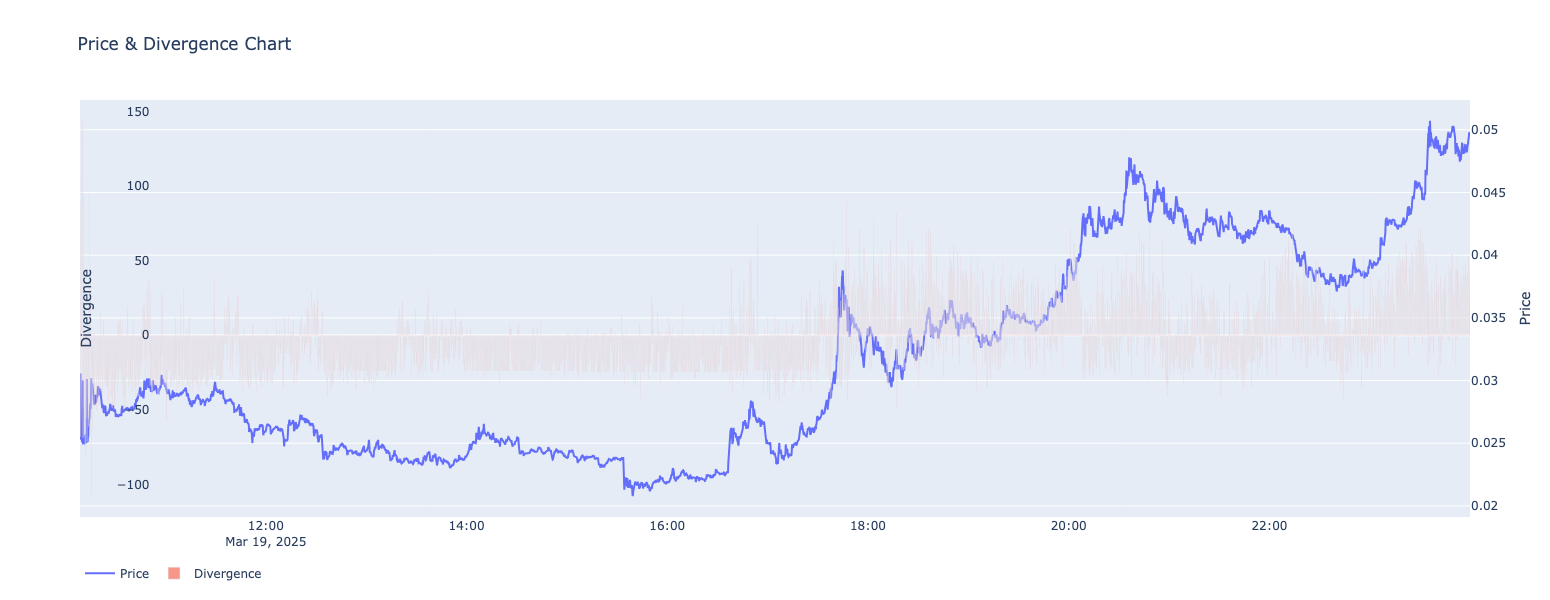

In [932]:
divergence_plot(arb_stats)

### Test

In [29]:
# # test
time = datetime.strptime('2024-11-27', '%Y-%m-%d')
exchanges = ['bybit-spot', 'kucoin-spot', 'gate-spot', 'okx-spot', 'binance-spot'] # 'kraken-spot'
data_types = ['book_ticker']
bybit_cat = Tardis_data.read(time, time, data_type=data_types[0], exchange='bybit-spot', symbol='catusdt')

gate_cat = Tardis_data.read(time, time, data_type=data_types[0], exchange='gate-io', symbol='cat_usdt')

In [370]:
div_bps_thresh = 0
arb_last_time = 200

exchanges = ['bybit-spot', 'kucoin-spot', 'gate-spot', 'okx-spot', 'binance-spot'] # 'kraken-spot'
data_types = ['book_ticker']
a, b = cross_arb_test('2024-11-27', '2024-11-27', exchanges, ['PEPE'], data_types, fees)
a

timestamp,ask_price_bybit-spot,bid_price_bybit-spot,ask_price_kucoin,bid_price_kucoin,ask_price_gate-io,bid_price_gate-io,ask_price_okex,bid_price_okex,ask_price_binance,bid_price_binance,best_ask,best_bid,bbo_divergence_bps
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1732665600530000,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,-17.8
1732665600540000,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,-17.8
1732665600550000,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,-17.8
1732665600560000,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,-17.8
1732665600570000,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,-17.8
…,…,…,…,…,…,…,…,…,…,…,…,…,…
1732751999950000,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,-15.4
1732751999960000,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,-15.4
1732751999970000,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,0.00002,-15.4


In [371]:
c = a.filter([
            pl.col('bbo_divergence_bps') >= div_bps_thresh
        ]).with_columns([
            pl.when(pl.col('timestamp').diff() > 20000)
            .then(pl.lit(1))
            .otherwise(pl.lit(0))
            .alias('new_arb')
        ]).with_columns([
            pl.col('new_arb').cum_sum().alias('bucket_id')
        ]).group_by('bucket_id').agg([
            pl.col('bbo_divergence_bps').max().alias('peak_divergece'),
            pl.col('timestamp').first().alias('arb_start_ts'),
            pl.col('timestamp').first().alias('arb_end_ts'),
            ((pl.col('timestamp').last() - pl.col('timestamp').first())/1000).alias('arb_last_time')
        ]).sort(by='bucket_id') # .filter(pl.col('arb_last_time') > arb_last_time)

In [342]:
c

bucket_id,peak_divergece,arb_start_ts,arb_end_ts,arb_last_time
i32,f64,i64,i64,f64
0,-8.5,1732665645010000,1732665645010000,1910.0
1,-9.6,1732665646980000,1732665646980000,0.0
2,-9.0,1732665647170000,1732665647170000,730.0
3,-9.6,1732665648000000,1732665648000000,70.0
4,-9.6,1732665648120000,1732665648120000,30.0
…,…,…,…,…
347,-8.0,1732750723780000,1732750723780000,40.0
348,-10.0,1732750736250000,1732750736250000,0.0
349,-0.9,1732750980390000,1732750980390000,50.0


In [133]:
d['max_bid'].value_counts().to_dict()

{'bybit-spot': 33, 'okex': 7, 'gate-io': 7, 'binance': 6}